<a href="https://colab.research.google.com/github/Bukasker/MK/blob/main/zad3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PIERWSZE 5 WIERSZY DANYCH ---
   x1  x2          y
0   1   2   4.361171
1   3   6  32.029778
2   5  10  63.867159
3   7  14  71.202104
4   9  18  16.762118

--- PODSTAWOWE STATYSTYKI OPISOWE ---
               x1          x2            y
count  110.000000  110.000000   110.000000
mean   110.000000  220.000000  1203.648374
std     63.796552  127.593103   924.706513
min      1.000000    2.000000     4.361171
25%     55.500000  111.000000   443.189943
50%    110.000000  220.000000  1022.823084
75%    164.500000  329.000000  1756.866885
max    219.000000  438.000000  3549.440299

--- MACIERZ KORELACJI ---
          x1        x2         y
x1  1.000000  1.000000  0.813719
x2  1.000000  1.000000  0.813719
y   0.813719  0.813719  1.000000

--- WYNIKI MODELU REGRESJI (Scikit-Learn) ---
Współczynnik kierunkowy (slope / beta_1): 11.2424
Wyraz wolny (intercept / beta_0): -79.2051
Współczynnik determinacji R^2 na zbiorze testowym: 0.6425
Błąd średniokwadratowy (MSE): 410047.2066

--- PEŁNE PODS

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


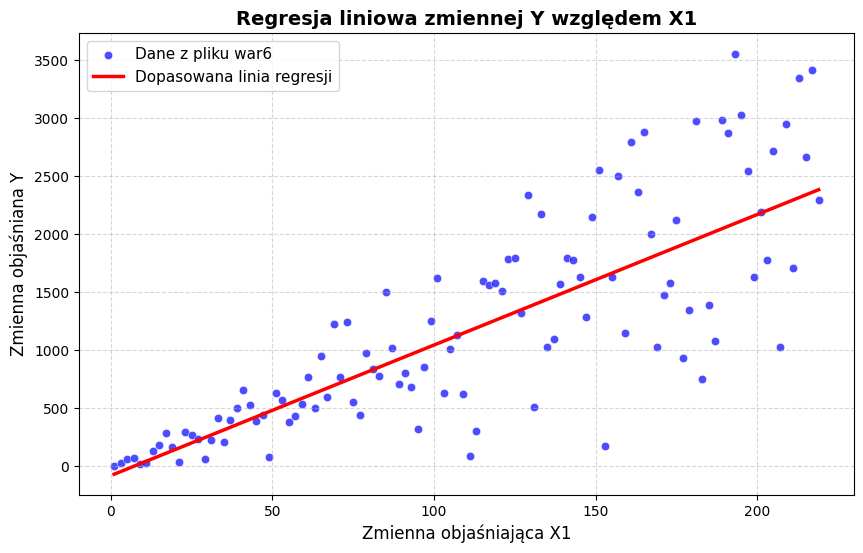

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================================================
# KROK 3: Wczytanie danych z uwzględnieniem formatowania pliku CSV
# ==============================================================================
# Twoja ścieżka do pliku (zauważ końcówkę .scv)
path = "/content/drive/MyDrive/Colab Notebooks/war6.csv"

# Plik używa średnika ';' jako separatora kolumn oraz przecinka ',' zamiast kropki dla liczb dziesiętnych
df = pd.read_csv(path, sep=';', decimal=',')

print("--- PIERWSZE 5 WIERSZY DANYCH ---")
print(df.head())
print("\n--- PODSTAWOWE STATYSTYKI OPISOWE ---")
print(df.describe())

# ==============================================================================
# KROK 4: Analiza korelacji (Wykrycie współliniowości)
# ==============================================================================
print("\n--- MACIERZ KORELACJI ---")
correlation_matrix = df.corr()
print(correlation_matrix)

# Ponieważ korelacja między x1 a x2 wynosi dokładnie 1.0 (doskonała zależność liniowa),
# nie możemy użyć obu tych zmiennych w klasycznym modelu regresji wielorakiej OLS.
# Musimy odrzucić jedną z nich (np. x2) i zbudować model y = f(x1).

# ==============================================================================
# KROK 5: Budowa modelu regresji liniowej (Scikit-Learn)
# ==============================================================================
X = df[['x1']]  # Zmienna objaśniająca
y = df['y']     # Zmienna objaśniana (cel)

# Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizacja i trenowanie modelu
model = LinearRegression()
model.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred = model.predict(X_test)

print("\n--- WYNIKI MODELU REGRESJI (Scikit-Learn) ---")
print(f"Współczynnik kierunkowy (slope / beta_1): {model.coef_[0]:.4f}")
print(f"Wyraz wolny (intercept / beta_0): {model.intercept_:.4f}")
print(f"Współczynnik determinacji R^2 na zbiorze testowym: {r2_score(y_test, y_pred):.4f}")
print(f"Błąd średniokwadratowy (MSE): {mean_squared_error(y_test, y_pred):.4f}")

# ==============================================================================
# KROK 6: Pełny raport statystyczny (Statsmodels) - opcjonalnie, często wymagany na uczelniach
# ==============================================================================
X_sm = sm.add_constant(X)  # Dodanie stałej (wyrazu wolnego) do modelu
model_sm = sm.OLS(y, X_sm).fit()

print("\n--- PEŁNE PODSUMOWANIE STATYSTYCZNE MODELU ---")
print(model_sm.summary())

# ==============================================================================
# KROK 7: Wykres i wizualizacja wyników
# ==============================================================================
plt.figure(figsize=(10, 6))

# Rysowanie punktów danych
sns.scatterplot(data=df, x='x1', y='y', color='blue', alpha=0.7, label='Dane z pliku war6')

# Generowanie linii regresji na pełnym zakresie danych
x_range = np.linspace(df['x1'].min(), df['x1'].max(), 100).reshape(-1, 1)
y_range_pred = model.predict(x_range)
plt.plot(x_range, y_range_pred, color='red', linewidth=2.5, label='Dopasowana linia regresji')

# Estetyka wykresu
plt.title('Regresja liniowa zmiennej Y względem X1', fontsize=14, fontweight='bold')
plt.xlabel('Zmienna objaśniająca X1', fontsize=12)
plt.ylabel('Zmienna objaśniana Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Wyświetlenie wykresu w Colab
plt.show()

In [3]:
!ls -a /content/.config

.
..
active_config
config_sentinel
configurations
default_configs.db
gce
hidden_gcloud_config_universe_descriptor_data_cache_configs.db
.last_opt_in_prompt.yaml
.last_survey_prompt.yaml
.last_update_check.json
logs
war6.csv
